In [2]:
import os 
os.environ["OMP_NUM_THREADS"] = "50"

In [3]:
import numpy as np
import healpy as hp
import astropy.units as u

import matplotlib.pyplot as plt
from pathlib import Path
from ds_utils import  *
from ps_utils import  *

In [4]:
cib_95_path = "/pscratch/sd/k/kp22/deft/mask_radio_cib_2mJy/mdpl2_95GHz_fullsky.fits"
cib_95_map = hp.read_map(cib_95_path)

In [3]:
cib_150_path = "/pscratch/sd/k/kp22/deft/mask_radio_cib_2mJy/mdpl2_150GHz_fullsky.fits"
cib_150_map = hp.read_map(cib_150_path)

In [7]:
cib_857_path = "/pscratch/sd/k/kp22/deft/mask_radio_cib_2mJy/mdpl2_857GHz_fullsky.fits"
cib_857_map = hp.read_map(cib_857_path)

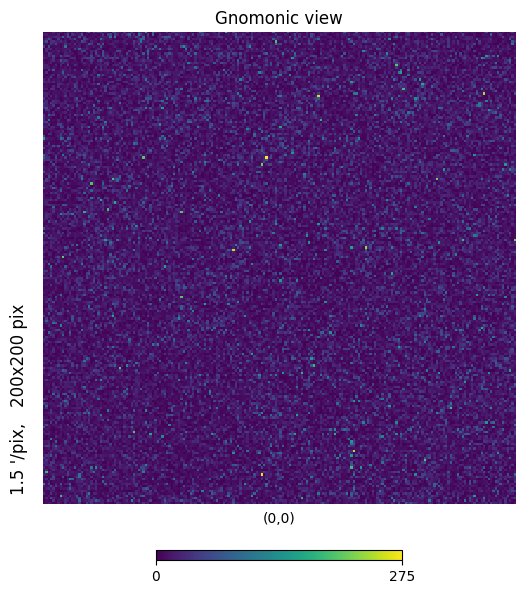

In [10]:
hp.gnomview(cib_150_map)

In [22]:
ptsrc_mask_150_path = "/pscratch/sd/k/kp22/deft/masks/mask_cibNG_radNG_spt3g_150_2.0mjy.fits"
ptsrc_mask_150_map = hp.read_map(ptsrc_mask_150_path)

In [30]:
cluster_mask_150_path = "/pscratch/sd/k/kp22/deft/masks/tsz_mask_8192_apodised_m500c3e+14.fits"
cluster_mask_150_map = hp.read_map(cluster_mask_150_path)

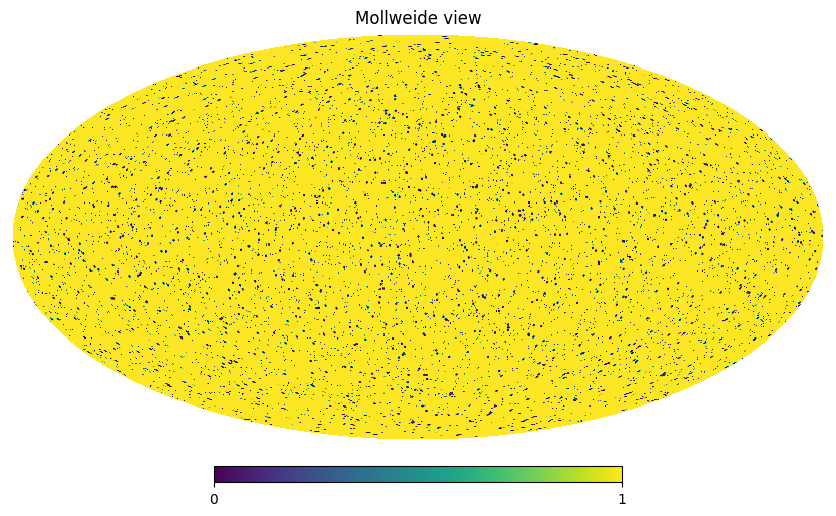

In [31]:
hp.mollview(cluster_mask_150_map)

In [32]:
np.mean(cluster_mask_150_map)

np.float32(0.9602577)

In [24]:
np.mean(ptsrc_mask_150_map)

np.float32(0.9999797)

In [8]:
tsz_150_path = "/pscratch/sd/k/kp22/deft/mask_radio_cib_2mJy/tsz/mdpl2_150GHz_fullsky.fits"
tsz_150_map = hp.read_map(tsz_150_path)

In [15]:
np.all(cib_150_map*ptsrc_mask_150_map == cib_150_map)

np.True_

In [16]:
np.all(tsz_150_map*ptsrc_mask_150_map == tsz_150_map)

np.True_

In [17]:
np.all(tsz_150_map*cluster_mask_150_map == tsz_150_map)

np.False_

In [18]:
masked_tsz_150_map = tsz_150_map*cluster_mask_150_map

In [19]:
np.std(masked_tsz_150_map), np.std(tsz_150_map)

(np.float32(3.2476516), np.float32(4.1060014))

In [20]:
np.min(cib_150_map),np.max(cib_150_map), np.mean(cib_150_map),np.std(cib_150_map)

(np.float32(-10.578293),
 np.float32(340.97406),
 np.float32(19.795933),
 np.float32(19.644127))

In [21]:
np.min(tsz_150_map),np.max(tsz_150_map), np.mean(tsz_150_map),np.std(tsz_150_map)

(np.float32(-806.5997),
 np.float32(27.343246),
 np.float32(-5.433948),
 np.float32(4.1060014))

In [22]:
np.min(masked_tsz_150_map),np.max(masked_tsz_150_map), np.mean(masked_tsz_150_map),np.std(masked_tsz_150_map)

(np.float32(-349.55157),
 np.float32(15.57192),
 np.float32(-5.088124),
 np.float32(3.2476516))

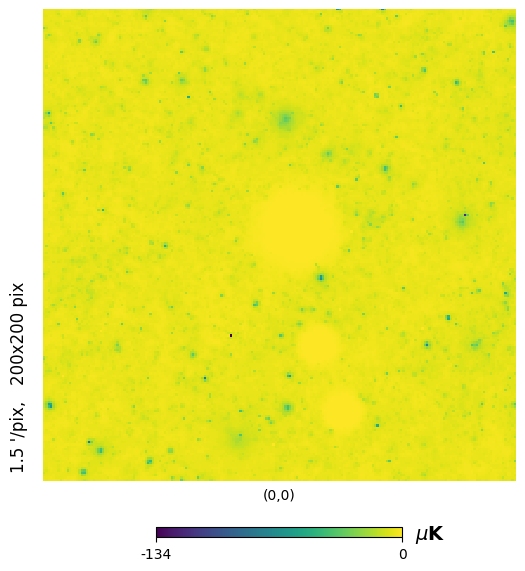

In [23]:
hp.gnomview(masked_tsz_150_map,title="",unit=r"$\mu$K", cmap='viridis',cbar=True)

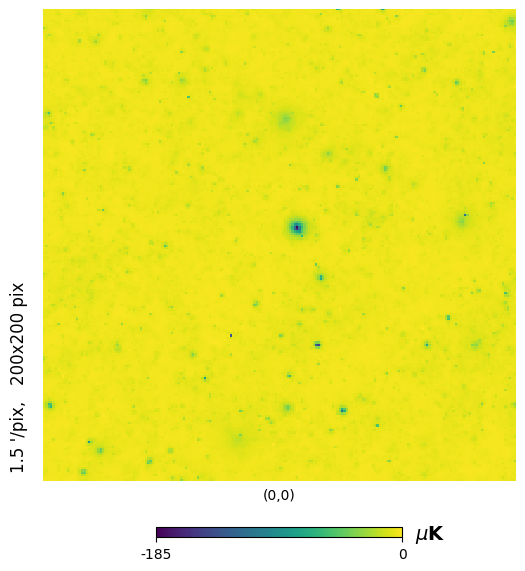

In [24]:
hp.gnomview(tsz_150_map,title="",unit=r"$\mu$K", cmap='viridis',cbar=True)

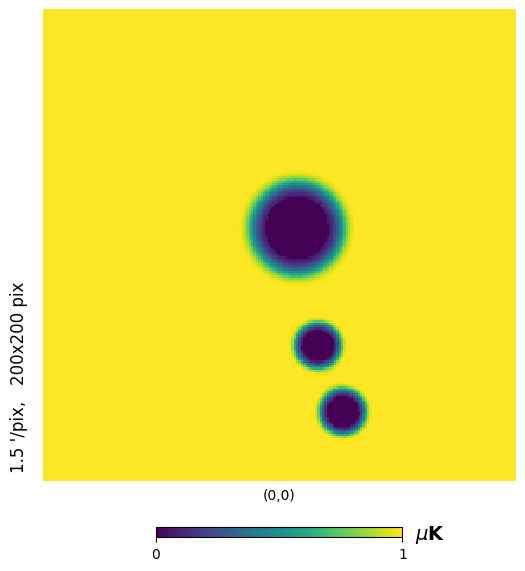

In [9]:
hp.gnomview(cluster_mask_150_map,title="",unit=r"$\mu$K", cmap='viridis',cbar=True)

In [49]:
boxsize_deg = 30
res_am = 10
boxsize = int(boxsize_deg*60/res_am) 

In [15]:
cluster_mask_150_map_binary = np.copy(cluster_mask_150_map)
cluster_mask_150_map_binary[cluster_mask_150_map_binary!=0]=1

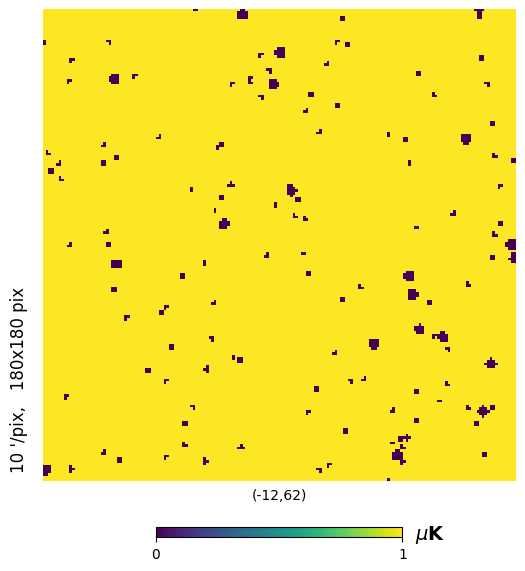

In [50]:
hp.gnomview(cluster_mask_150_map_binary,xsize = boxsize, rot=[-12,62] ,reso=res_am, title="",unit=r"$\mu$K", cmap='viridis',cbar=True)

In [26]:
mean_val = np.mean(masked_tsz_150_map)
std_val = np.std(masked_tsz_150_map)

mask = cluster_mask_150_map < 1
masked_tsz_150_map[mask] = np.random.normal(mean_val, std_val, size=np.sum(mask))

In [27]:
masked_tsz_150_path = "/pscratch/sd/k/kp22/deft/mask_radio_cib_2mJy/tsz/mdpl2_150GHz_fullsky_mask_3e+14.fits"
hp.write_map(masked_tsz_150_path, masked_tsz_150_map,overwrite=True)

setting the output map dtype to [dtype('float32')]


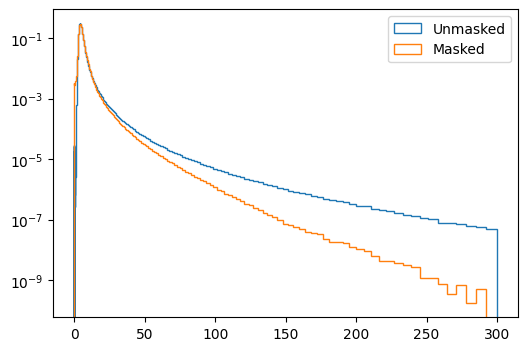

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(-1*tsz_150_map.flatten(),bins=np.logspace(np.log10(0.001),np.log10(300.0), 500), histtype='step', density=True, linewidth=1, label='Unmasked')
ax.hist(-1*masked_tsz_150_map.flatten(),bins=np.logspace(np.log10(0.001),np.log10(300.0), 500), histtype='step', density=True, linewidth=1, label='Masked')
plt.yscale('log')
plt.legend()